In [2]:
#setup
from mlwpy import *
diabetes = datasets.load_diabetes()
%matplotlib inline

In [3]:
N = 20
ftr = np.linspace(-10,10,num= N) #ftr values
tgt = 2 * ftr**2 - 3 + np.random.uniform(-2,2,N) #tgt = func(ftr)

(train_ftr,test_ftr,train_tgt,test_tgt) = skms.train_test_split(ftr,tgt,test_size=N//2)

display(pd.DataFrame({"ftr":train_ftr,"tgt":train_tgt}).T)
                            

,0,1,2,3,4,5,6,7,8,9
ftr,-1.5789,-6.8421,-3.6842,1.5789,-7.8947,3.6842,7.8947,4.7368,5.7895,-0.5263
tgt,2.3906,91.0234,22.3791,3.8658,122.5817,22.9962,121.7528,40.6026,62.7696,-1.6137


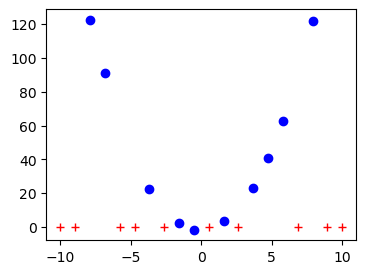

In [4]:
plt.plot(train_ftr,train_tgt, 'bo')
plt.plot(test_ftr, np.zeros_like(test_ftr), 'r+')

In [5]:
#now we will reshape since sklearn wants 2D shape
sk_model = linear_model.LinearRegression()
sk_model.fit(train_ftr.reshape(-1,1),train_tgt)
sk_preds = sk_model.predict(test_ftr.reshape(-1,1))
sk_preds[:3]

array([53.218 , 41.4552, 56.8374])

In [6]:
#fit-predit evaluate a 1D po;ynomial (a line)
model_one = np.poly1d(np.polyfit(train_ftr,train_tgt,1))
preds_one = model_one(test_ftr)
print(preds_one[:3])

[53.218  41.4552 56.8374]


In [7]:
#the predictions come back to the same
print("all close?",np.allclose(sk_preds,preds_one))

#lets use mean square error to check if they actually align
mse = metrics.mean_squared_error
print("RMSE:",np.sqrt(mse(test_tgt,preds_one)))

all close? True
RMSE: 86.69151817350722


In [8]:
#now lets try with polynomial model with 2 degree
model_two = np.poly1d(np.polyfit(train_ftr,train_tgt,2))
preds_two = model_two(test_ftr)
print("RMSE:",np.sqrt(mse(test_tgt,preds_two)))

RMSE: 1.276599218888112


In [9]:
model_three = np.poly1d(np.polyfit(train_ftr,train_tgt,9))
preds_three = model_three(test_ftr)
print("RMSE:",np.sqrt(mse(test_tgt,preds_three)))

RMSE: 317.36344242359115


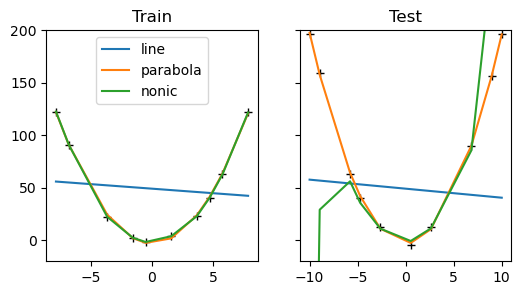

In [10]:
fig,axes = plt.subplots(1,2,figsize= (6,3),sharey= True)

labels = ['line','parabola','nonic']
models = [model_one, model_two, model_three]
train = (train_ftr,train_tgt)
test = (test_ftr, test_tgt)

for ax, (ftr,tgt) in zip(axes, [train,test]):
    ax.plot(ftr,tgt,'k+')
    for m, lbl in zip(models,labels):
        ftr = sorted(ftr)
        ax.plot(ftr,m(ftr),'-',label=lbl)



axes[1].set_ylim(-20,200)
axes[0].set_title("Train")
axes[1].set_title("Test")
axes[0].legend(loc='upper center');


In [11]:
results = []
for complexity in [1,2,6,9]:
    model=np.poly1d(np.polyfit(train_ftr,train_tgt,complexity))
    train_error = np.sqrt(mse(train_tgt,model(train_ftr)))
    test_error = np.sqrt(mse(test_tgt,model(test_ftr)))
    results.append((complexity,train_error,test_error))
columns = ["Complexity","Train Error","Test Error"]
results_df = pd.DataFrame.from_records(results,columns = columns, index="Complexity")
results_df

,Train Error,Test Error
Complexity,,
1,45.4951,86.6915
2,1.0828,1.2766
6,0.2819,6.1417
9,0.0000,317.3634


<Axes: xlabel='Complexity'>

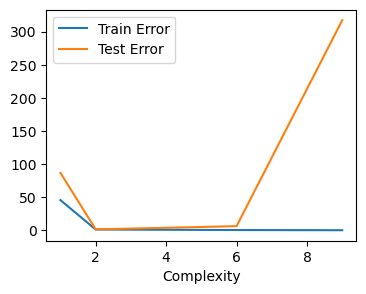

In [12]:
results_df.plot()

In [13]:
def training_loss(loss,model, training_data):
    ' total training_loss on train_data with model under loss'
    return sum(loss(model.predict(x.reshape(1,-1)),y)
                            for x,y in training_data)\

def squared_error(prediction,actual):
    'squared error on as single example'
    return (prediction-actual)**2

#could be used like
#my_training_loss = training_loss(squared_error, model, training_data)

In [14]:
knn = neighbors.KNeighborsRegressor(n_neighbors=3)
fit = knn.fit(diabetes.data, diabetes.target)

training_data = zip(diabetes.data,diabetes.target)

my_training_loss = training_loss(squared_error, knn, training_data)

print(my_training_loss)

[863792.3333]


In [15]:
mse = metrics.mean_squared_error(diabetes.target, knn.predict(diabetes.data))

print(mse*len(diabetes.data))

863792.3333333333


In [16]:
def complexity(model):
    return model.complexity

def cost(model,training_data,_lambda,loss):
    return training_loss(m,D) + _lambda*complexity(m)

In [17]:
model = neighbors.KNeighborsRegressor(10)
skms.cross_val_score(
    model,
    diabetes.data,
    diabetes.target,
    cv=5,
    scoring = 'neg_mean_squared_error'
)

#notes
#defaults for cross_val_score are
# cv=3 fold, no shuffle, stratified if classifier
# model.score by default (regressors: r2, classifiers: accuracy)

array([-3206.7542, -3426.4313, -3587.9422, -3039.4944, -3282.6016])

In [18]:
iris = datasets.load_iris()
model = neighbors.KNeighborsClassifier(10)
skms.cross_val_score(model,iris.data,iris.target,cv = 5)

array([0.9667, 1.    , 1.    , 0.9333, 1.    ])

In [19]:
pet = np.array(['cat','dog','cat',
               'dog','dog','dog'])
list_folds = list(skms.KFold(2).split(pet))
training_idxs = np.array(list_folds)[:,0,:]
print(pet[training_idxs])

[['dog' 'dog' 'dog']
 ['cat' 'dog' 'cat']]


In [22]:
pet = np.array(['cat','dog','cat',
               'dog','dog','dog'])
idxs = np.array(list(skms.StratifiedKFold(2).split(np.ones_like(pet),pet)))
training_idxs = idxs[:,0,:]
print(pet[training_idxs])

[['cat' 'dog' 'dog']
 ['cat' 'dog' 'dog']]


In [23]:
iris = datasets.load_iris()
model = neighbors.KNeighborsClassifier(5)
non_strat_kf = skms.KFold(5)
skms.cross_val_score(model,iris.data,iris.target,cv = non_strat_kf)

array([1.    , 1.    , 0.8333, 0.9333, 0.8   ])

In [28]:
linreg = linear_model.LinearRegression()
diabetes = datasets.load_diabetes()

scores = []
for r in range(10):
    tts = skms.train_test_split(diabetes.data,diabetes.target,test_size = 0.25)
    (diabetes_train_ftrs,diabetes_test_ftrs,diabetes_train_tgt,diabetes_test_tgt) = tts

    fit = linreg.fit(diabetes_train_ftrs,diabetes_train_tgt)
    preds= fit.predict(diabetes_test_ftrs)

    score = metrics.mean_squared_error(diabetes_test_tgt,preds)
    scores.append(score)

scores = pd.Series(np.sqrt(sorted(scores)))
df = pd.DataFrame({'RMSE':scores})
df.index.name = 'Repeat'
display(df.T)

Repeat,0,1,2,3,4,5,6,7,8,9
RMSE,53.0500,53.5060,53.9466,54.4353,54.8168,54.9607,56.0309,57.0986,58.6854,64.8587


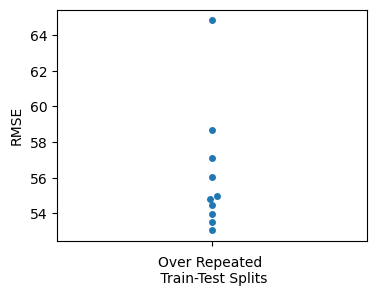

In [29]:
ax = plt.figure(figsize=(4,3)).gca()
sns.swarmplot(y='RMSE',data= df,ax=ax)
ax.set_xlabel('Over Repeated \n Train-Test Splits');

In [ ]:
display(df.describe().T)